# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [3]:
df.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [4]:
monthly_rents = df['count'].resample('ME').mean()

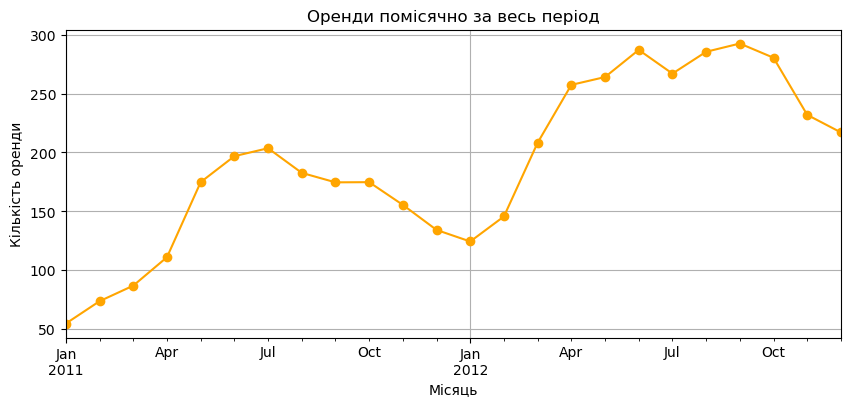

In [5]:
monthly_rents.plot(
    kind='line',
    marker='o',
    figsize=(10, 4),
    color='orange',
    title='Оренди помісячно за весь період',
    xlabel='Місяць',
    ylabel='Кількість оренди',
    grid=True
);

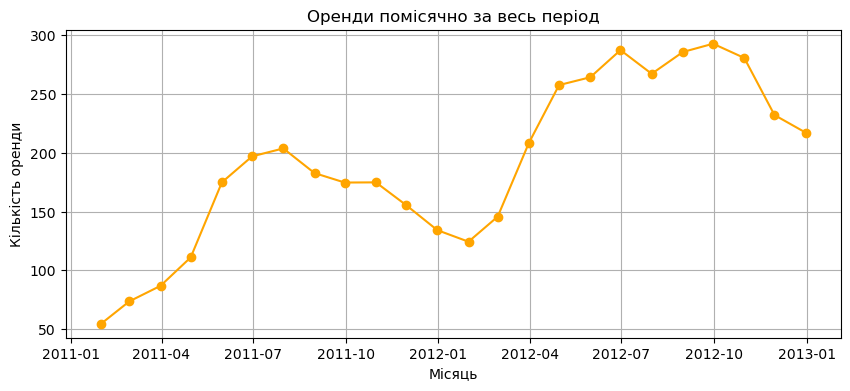

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(monthly_rents.index, monthly_rents.values, marker='o', color='orange')
plt.title('Оренди помісячно за весь період')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.grid(True);

Графіки відрізняються сіткою (з plt отримуємо і вертикальні лінії сітки по замовчуванню); підписами даних на осі ОХ (з plt замість назв місяців маємо певний формат дати); початок та кінець графіку з plt не перетинається з віссю ОУ ліворуч та вертикальною межею графіку праворуч, наче є вільний простір. Для подібного завдання більше подобається DataFrame.plot(), бо на однакову кількість коду менше потрібно допрацьовувати надписів.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [7]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

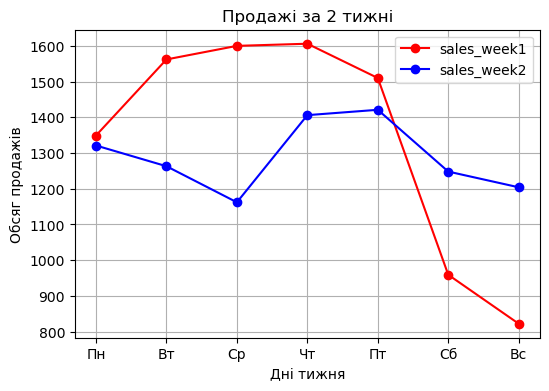

In [8]:
labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
labels2 = ['sales_week1', 'sales_week2']
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(days, sales_week1, 'o-', label='sales_week1', color='red')
ax.plot(days, sales_week2, 'o-', label='sales_week1', color='blue')
ax.set_xticks(days, labels)

plt.title('Продажі за 2 тижні')
plt.xlabel('Дні тижня')
plt.ylabel('Обсяг продажів')
plt.grid(True)
plt.legend(labels2);

1. Найбльш стабільні продажі спостерігаємо в другий тиждень (діапазон близько 270 одиниць), натомість в перший тиждень діапазон змін близько 800 одиниць.

2. Можна знайти різницю між максимальною та мінімальною точкою на графіку. Також можна обчислити среднє значення та стандартне відхилення. Також візуально це можна бачити за допомогою графіку boxplot. 

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [9]:
monthly_temp = df['temp'].resample('ME').mean()
quaterly_rents = df['count'].resample('QE').mean()
hourly_humidity = df['humidity']
temperature = df['temp']
rents = df['count']

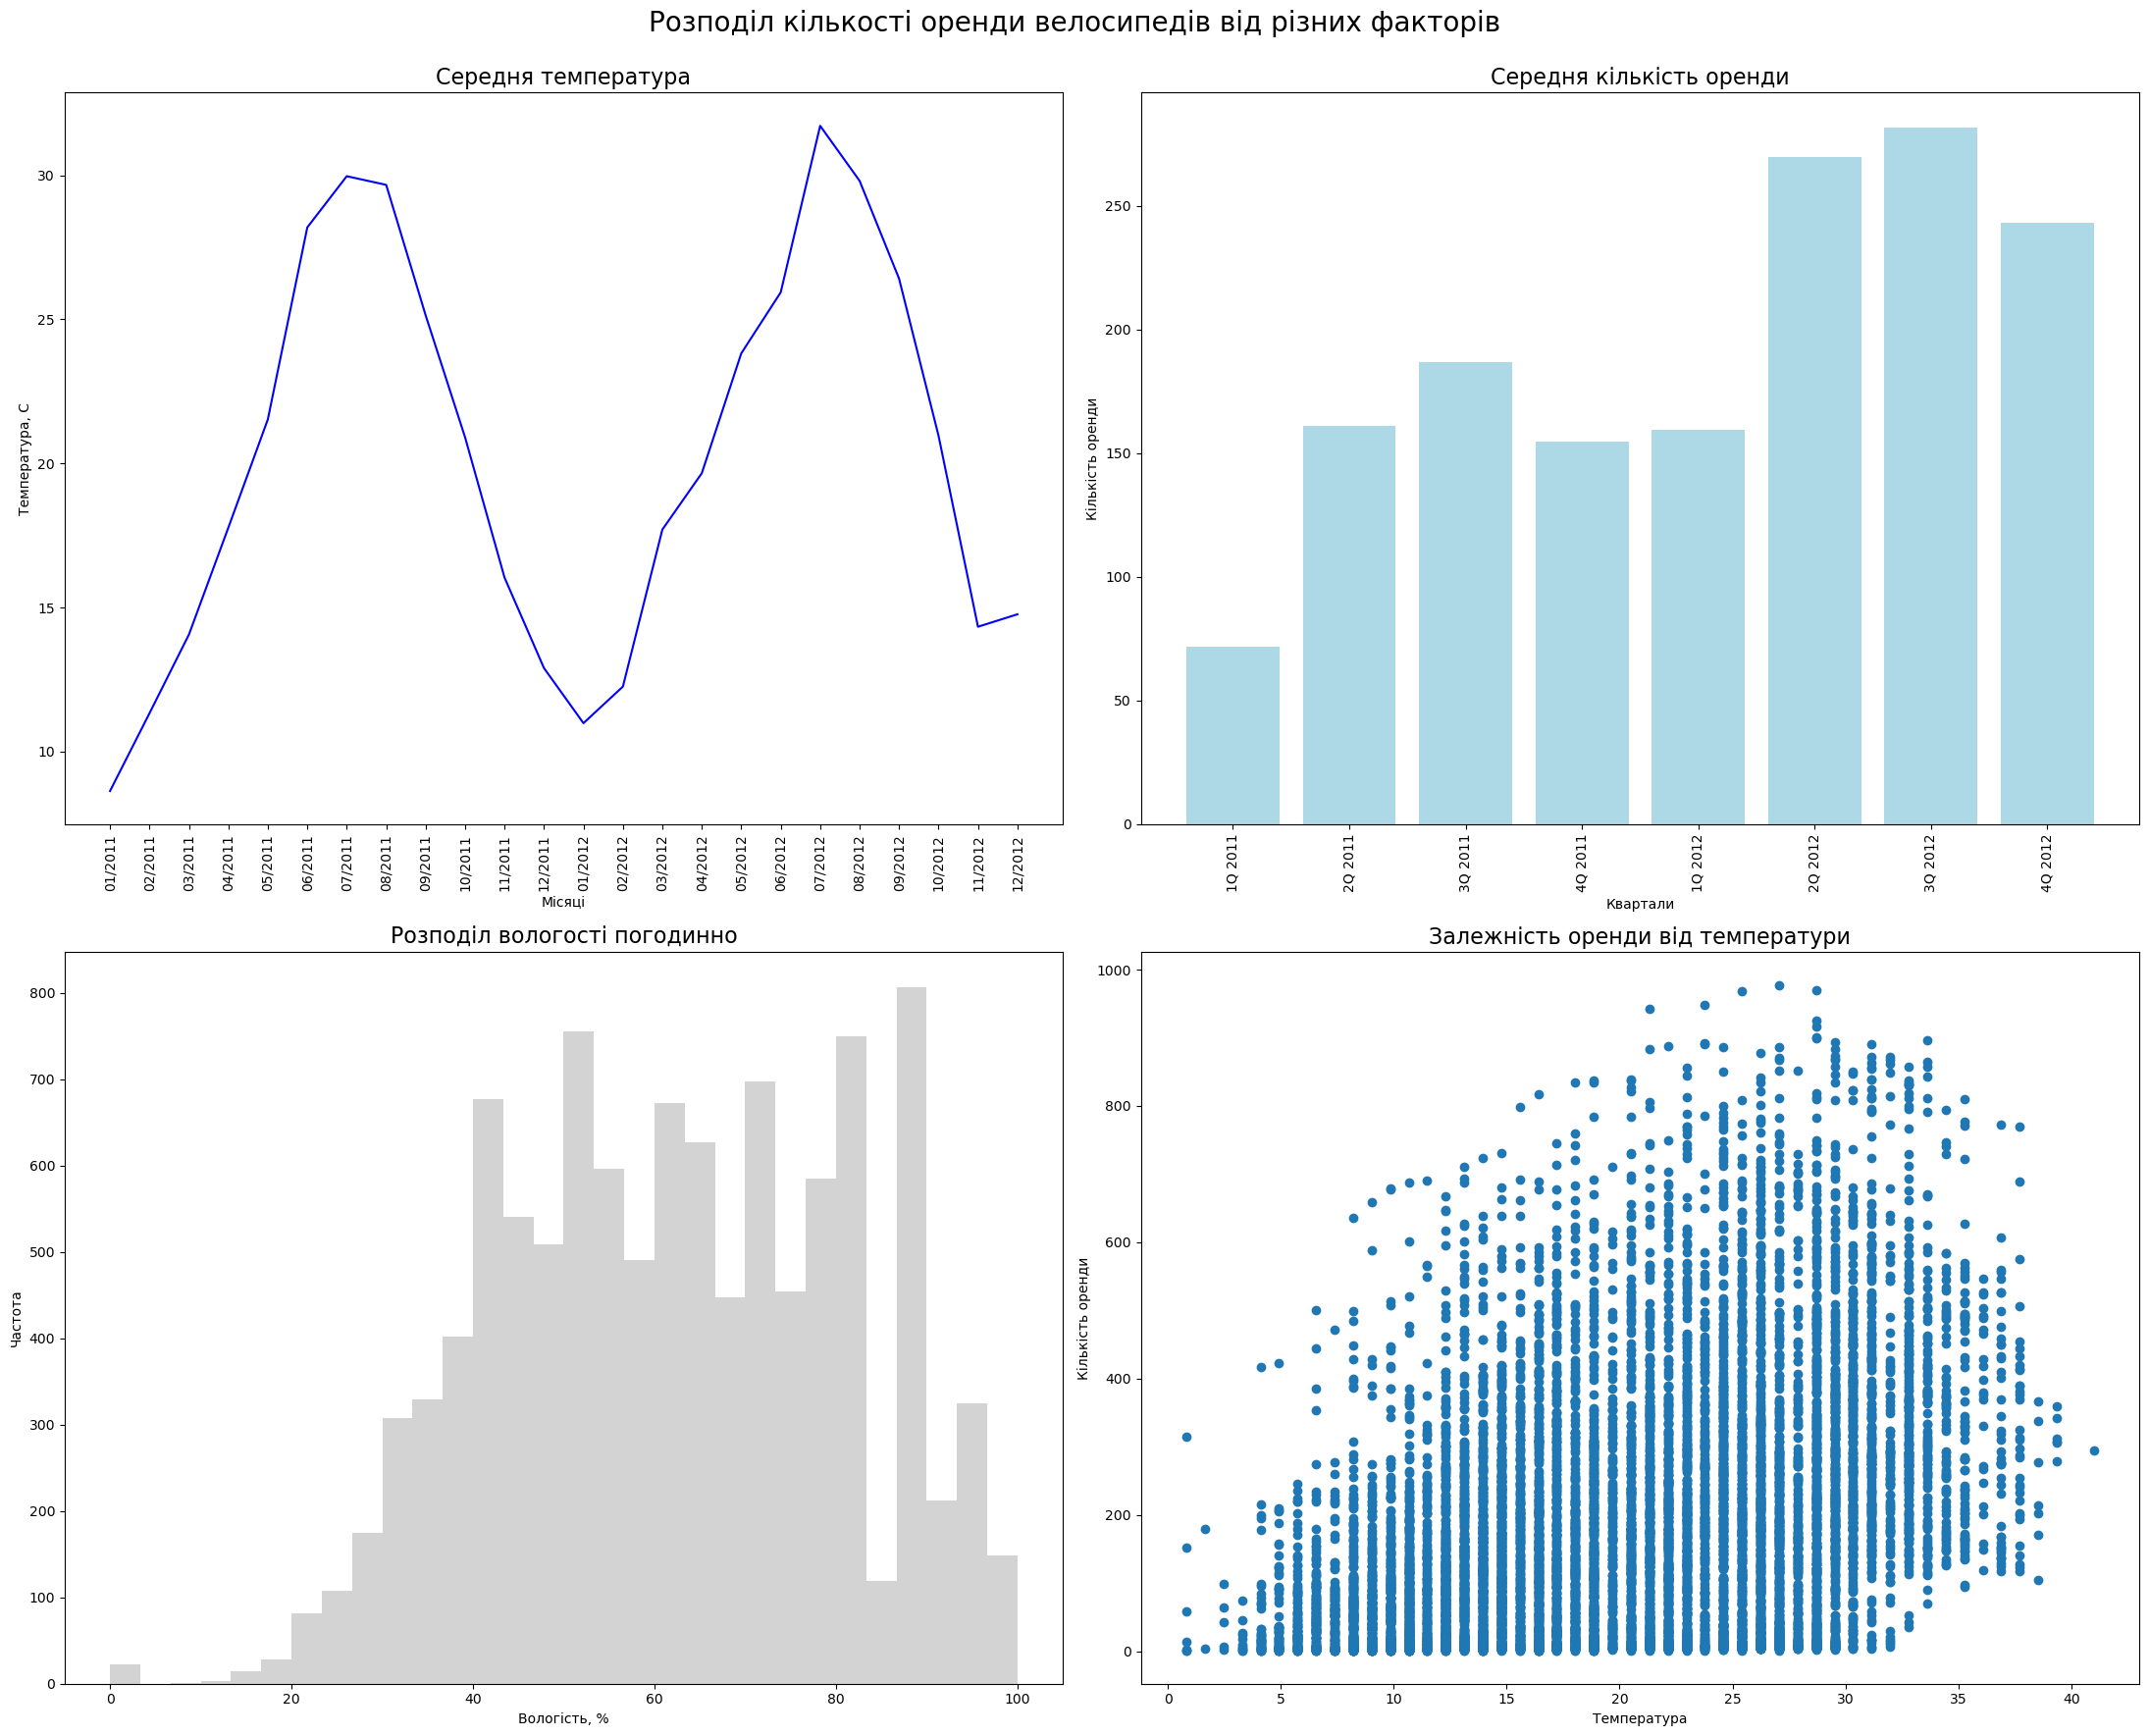

In [10]:
plt.figure(figsize=(22, 18))
quarters = ['1Q 2011', '2Q 2011','3Q 2011','4Q 2011','1Q 2012','2Q 2012','3Q 2012','4Q 2012']
monthes = ['01/2011', '02/2011','03/2011','04/2011','05/2011','06/2011','07/2011','08/2011',
           '09/2011','10/2011','11/2011','12/2011','01/2012','02/2012','03/2012','04/2012',
           '05/2012','06/2012','07/2012','08/2012',
           '09/2012','10/2012','11/2012','12/2012']

# Графік 1
plt.subplot(2, 2, 1)
plt.plot(monthes, monthly_temp, color='blue')
plt.title('Cередня температура', fontsize=16)
plt.xlabel('Місяці')
plt.ylabel('Температура, С')
plt.xticks(rotation=90)

# Графік 2
plt.subplot(2, 2, 2)
plt.bar(quarters, quaterly_rents, color='lightblue')
plt.title('Середня кількість оренди', fontsize=16)
plt.xlabel('Квартали')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=90)

# Графік 3
plt.subplot(2, 2, 3)
plt.hist(hourly_humidity, bins=30, color='lightgrey')
plt.title('Розподіл вологості погодинно', fontsize=16)
plt.xlabel('Вологість, %')
plt.ylabel('Частота')

# Графік 4
plt.subplot(2, 2, 4)
plt.scatter(temperature, rents)
plt.title('Залежність оренди від температури', fontsize=16)
plt.xlabel('Температура')
plt.ylabel('Кількість оренди')

plt.suptitle('Розподіл кількості оренди велосипедів від різних факторів', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

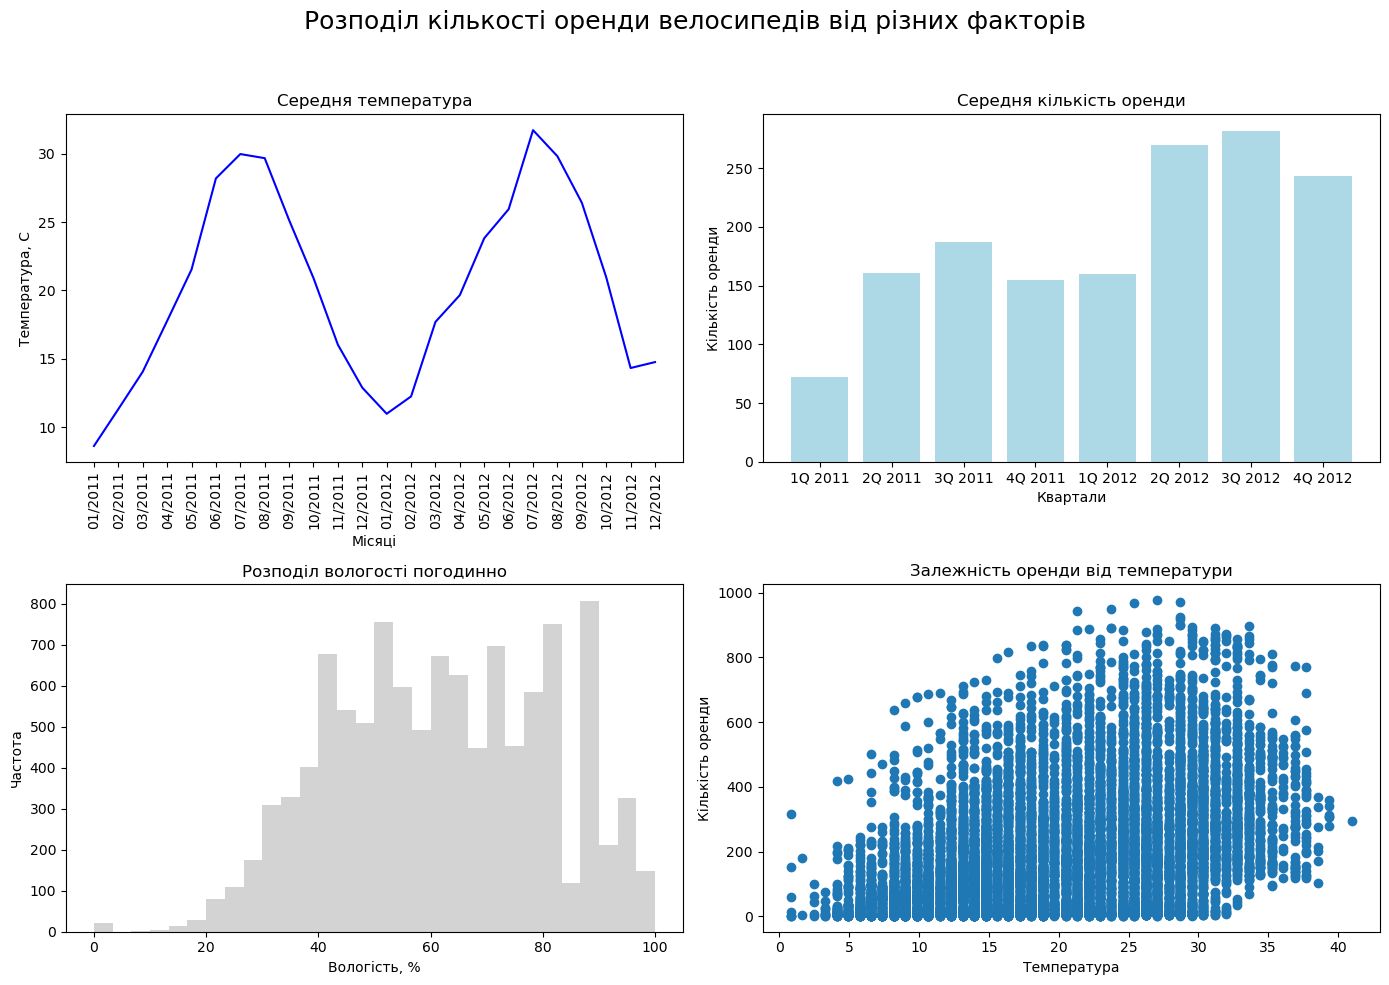

In [11]:
quarters = ['1Q 2011', '2Q 2011','3Q 2011','4Q 2011','1Q 2012','2Q 2012','3Q 2012','4Q 2012']
monthes = ['01/2011', '02/2011','03/2011','04/2011','05/2011','06/2011','07/2011','08/2011',
           '09/2011','10/2011','11/2011','12/2011','01/2012','02/2012','03/2012','04/2012',
           '05/2012','06/2012','07/2012','08/2012',
           '09/2012','10/2012','11/2012','12/2012']

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Верхній лівий — plot
ax[0, 0].plot(monthes, monthly_temp, color='blue')
ax[0, 0].set_title('Cередня температура')
ax[0, 0].set_xlabel('Місяці')
ax[0, 0].set_ylabel('Температура, С')
ax[0, 0].tick_params(axis='x', rotation=90)

# Верхній правий — bar
ax[0, 1].bar(quarters, quaterly_rents, color='lightblue')
ax[0, 1].set_title('Середня кількість оренди')
ax[0, 1].set_xlabel('Квартали')
ax[0, 1].set_ylabel('Кількість оренди')

# Нижній лівий — histogram
ax[1, 0].hist(hourly_humidity, bins=30, color='lightgrey')
ax[1, 0].set_title('Розподіл вологості погодинно')
ax[1, 0].set_xlabel('Вологість, %')
ax[1, 0].set_ylabel('Частота')

# Нижній правий — scatter
ax[1, 1].scatter(temperature, rents)
ax[1, 1].set_title('Залежність оренди від температури')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренди')

fig.suptitle('Розподіл кількості оренди велосипедів від різних факторів', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [12]:
import matplotlib.dates as mdates

In [18]:
monthly_rents2 = df['count'].resample('ME').agg(['mean', 'max', 'min'])
monthly_rents2

,mean,max,min
datetime,,,
2011-01-31,54.645012,219,1
2011-02-28,73.641256,327,1
2011-03-31,86.849776,332,1
2011-04-30,111.026374,452,1
2011-05-31,174.809211,611,1
2011-06-30,196.877193,638,1
2011-07-31,203.614035,596,1
2011-08-31,182.666667,600,1
2011-09-30,174.622517,628,1


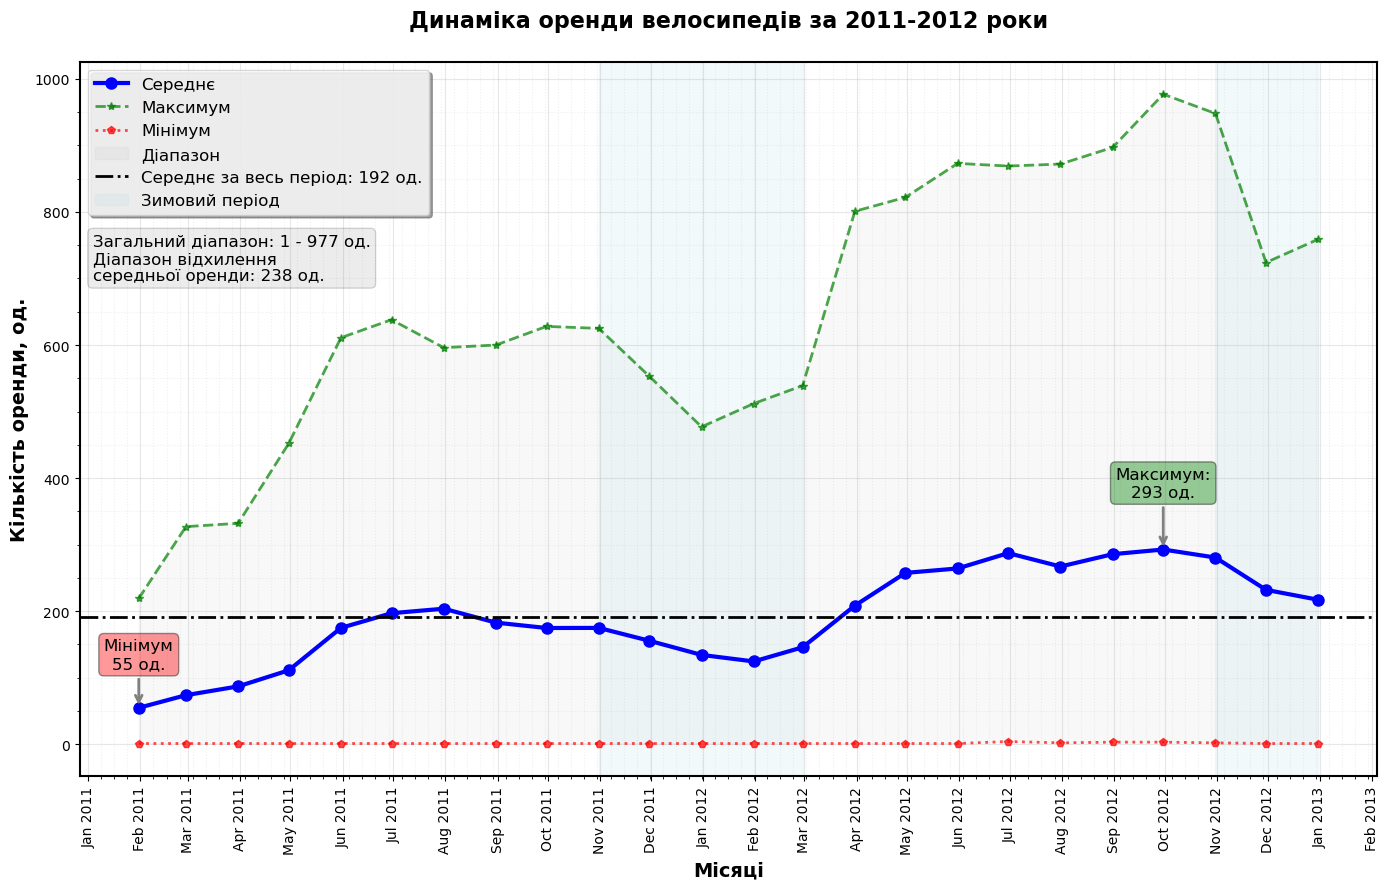

In [132]:
fig, ax = plt.subplots(figsize=(14, 9))

# лінії
ax.plot(monthly_rents2.index, monthly_rents2['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_rents2.index, monthly_rents2['max'], 'g--*', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_rents2.index, monthly_rents2['min'], 'r:p', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min 
ax.fill_between(monthly_rents2.index, monthly_rents2['min'], monthly_rents2['max'],
                alpha=0.05, color='gray', label='Діапазон')

#  Анотації для екстремальних значень
max_idx = monthly_rents2['mean'].idxmax()
max_val = monthly_rents2['mean'].max()
ax.annotate(f'Максимум:\n{max_val:.0f} од.',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 80),
            arrowprops=dict(arrowstyle='->', color='grey', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.4))

min_idx = monthly_rents2['mean'].idxmin()
min_val = monthly_rents2['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f} од.',
            xy=(min_idx, min_val), xytext=(min_idx, min_val + 60),
            arrowprops=dict(arrowstyle='->', color='grey', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.4))

# Налаштування осей
ax.set_xlabel('Місяці', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренди, од.', fontsize=14, fontweight='bold')
ax.set_title('Динаміка оренди велосипедів за 2011-2012 роки',
             fontsize=16, fontweight='bold', pad=25)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=90)

# Сітка
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Середня лінія
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='black', linestyle='-.', linewidth=2,
           label=f'Середнє за весь період: {overall_mean:.0f} од.')

# Зима
if len(monthly_rents2) >= 24:
    ax.axvspan(monthly_rents2.index[9], monthly_rents2.index[13], alpha=0.15,
               color='lightblue', label='Зимовий період')
if len(monthly_rents2) >= 24:
    ax.axvspan(monthly_rents2.index[21], monthly_rents2.index[23], alpha=0.15,
               color='lightblue')

# Легенда
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.8)

# Додаткова статистика
textstr = f'Загальний діапазон: {monthly_rents2["min"].min():.0f} - {monthly_rents2["max"].max():.0f} од.\n'
textstr += f'Діапазон відхилення\nсередньої оренди: {max_val - min_val:.0f} од.'
props = dict(boxstyle='round', facecolor='grey', alpha=0.15)
ax.text(0.01, 0.69, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', bbox=props)

# Рамка
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


1. Яка перевага додавання анотацій на графік? Можна вказати пікові точки даних, акцентувати на них увагу.
2. Для чого використовується fill_between()? На даному графіку для кращого візуального фокусу користувача на діапазоні між максимальними та мінімальними значеннями даних. В цілому це заливка площі фігури між двома лінійними графіками.
3. Як текстовий блок допомагає в інтерпретації даних? В текстовий блок можна винести основні показники даних: середнє, мін, макс, відхилення тощо (основні показники вибірки).